# 03 — Algorithm Benchmarking

Compare three beamforming algorithms on synthetic multi-source scenarios:
- **D&S** — Conventional Delay-and-Sum (matched filter, reference)
- **MVDR** — Minimum Variance Distortionless Response (Capon)
- **CLEAN-SC** — Iterative deconvolution using source coherence

**Method:** Generate synthetic microphone signals from known far-field point sources,
compute the Cross-Spectral Matrix (CSM), then apply each beamformer.
Array geometry: Underbrink H=12×8, α=22° (primary candidate from notebook 02).

**Scenarios evaluated:**
1. Single source — verify DoA accuracy and map quality
2. Two equal-power sources, well-separated (30°)
3. Two equal-power sources, close together (1× HPBW ≈ 9° at 4 kHz)
4. Two sources with 20 dB power difference (weak source detection)

**Metrics:** DoA error (°), dynamic range (dB), HPBW of recovered source map.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import inv

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C      = 343.0
R_MAX  = 0.150
R_MIN  = 0.025
FS     = 48000
NFFT   = 1024
N_SNAP = 256   # number of time snapshots for CSM estimation

## Array Geometry

In [2]:
def underbrink_array(n_arms, n_per_arm, r_min=R_MIN, r_max=R_MAX, spiral_angle_deg=22.0):
    """Equal arc-length Underbrink multi-arm log-spiral."""
    b         = 1.0 / np.tan(np.radians(spiral_angle_deg))
    sq        = np.sqrt(1.0 + b**2)
    theta_max = np.log(r_max / r_min) / b
    S_total   = r_min * sq / b * (np.exp(b * theta_max) - 1.0)
    s         = np.linspace(0.0, S_total, n_per_arm)
    theta_arm = np.log(1.0 + b * s / (r_min * sq)) / b
    r_arm     = r_min * np.exp(b * theta_arm)
    xs, ys = [], []
    for h in range(n_arms):
        offset = h * 2.0 * np.pi / n_arms
        t = theta_arm + offset
        xs.append(r_arm * np.cos(t))
        ys.append(r_arm * np.sin(t))
    return np.concatenate(xs), np.concatenate(ys)


x_arr, y_arr = underbrink_array(12, 8)   # H=12×8, primary candidate
N_MICS = len(x_arr)
print(f"Array: {N_MICS} mics")

Array: 96 mics


## Synthetic Signal Generation

For each source at far-field direction `az_deg`, the steering vector is:

$$\mathbf{h}(\theta, f) = \frac{1}{\sqrt{N}} \exp\!\left( j \frac{2\pi f}{c} \sin(\theta) \, \mathbf{x} \right)$$

The received signal is the sum of source contributions plus additive white Gaussian noise.
The Cross-Spectral Matrix (CSM) is estimated by averaging over `N_SNAP` snapshots:

$$\hat{\mathbf{R}} = \frac{1}{N_{\text{snap}}} \sum_k \mathbf{y}_k \mathbf{y}_k^H$$

In [3]:
rng = np.random.default_rng(42)


def steering_vector(x, y, az_deg, freq):
    """Far-field steering vector (normalised), elevation = 0."""
    u = np.sin(np.radians(az_deg))
    phase = 2 * np.pi * freq / C * u * x
    h = np.exp(1j * phase) / np.sqrt(len(x))
    return h  # shape (N_MICS,)


def make_csm(x, y, sources, freq, snr_db=20, n_snap=N_SNAP):
    """
    Build the CSM for a list of (az_deg, power_linear) sources.
    Noise power is set so that the loudest source has the given SNR.
    Returns (N_MICS × N_MICS) complex CSM.
    """
    N = len(x)
    # Noise power from SNR of the loudest source
    max_power = max(p for _, p in sources)
    noise_var = max_power / (10 ** (snr_db / 10))

    R = np.zeros((N, N), dtype=complex)
    for _ in range(n_snap):
        y_snap = np.zeros(N, dtype=complex)
        for az, power in sources:
            h = steering_vector(x, y, az, freq)
            # Circularly-symmetric complex Gaussian source signal
            s = rng.standard_normal() + 1j * rng.standard_normal()
            y_snap += np.sqrt(power / 2) * h * s
        # Additive white noise
        noise = rng.standard_normal(N) + 1j * rng.standard_normal(N)
        y_snap += np.sqrt(noise_var / 2) * noise
        R += np.outer(y_snap, y_snap.conj())
    return R / n_snap

## Beamformer Implementations

All beamformers scan a 1D azimuth grid and return a real-valued power map.

In [4]:
def scan_grid(n_points=1000, az_range=(-60, 60)):
    return np.linspace(*az_range, n_points)


def beamform_ds(x, y, R, freq, az_grid):
    """
    Conventional Delay-and-Sum (matched filter).
    P_DS(theta) = h^H R h
    """
    out = np.zeros(len(az_grid))
    for i, az in enumerate(az_grid):
        h = steering_vector(x, y, az, freq)
        out[i] = np.real(h.conj() @ R @ h)
    return out


def beamform_mvdr(x, y, R, freq, az_grid, diag_load=0.01):
    """
    MVDR / Capon beamformer.
    P_MVDR(theta) = 1 / (h^H R^{-1} h)
    Diagonal loading for numerical stability.
    """
    N = R.shape[0]
    R_loaded = R + diag_load * np.trace(R) / N * np.eye(N)
    R_inv = inv(R_loaded)
    out = np.zeros(len(az_grid))
    for i, az in enumerate(az_grid):
        h = steering_vector(x, y, az, freq)
        denom = np.real(h.conj() @ R_inv @ h)
        out[i] = 1.0 / denom if denom > 0 else 0.0
    return out


def beamform_cleansc(x, y, R, freq, az_grid, n_iter=10, loop_gain=0.5):
    """
    CLEAN-SC (Sijtsma 2007).
    Iteratively subtract the dominant source's contribution (scaled by its
    coherence with the array) from the CSM.
    """
    N = R.shape[0]
    R_work = R.copy()
    source_map = np.zeros(len(az_grid))

    for _ in range(n_iter):
        # Find peak of current D&S map
        ds = beamform_ds(x, y, R_work, freq, az_grid)
        peak_idx = np.argmax(ds)
        peak_az  = az_grid[peak_idx]
        peak_pow = ds[peak_idx]

        # Source-coherence vector: column of R_work steered to peak
        h_peak = steering_vector(x, y, peak_az, freq)
        g = R_work @ h_peak            # shape (N,)
        strength = np.real(h_peak.conj() @ g)

        # Accumulate into clean map
        source_map[peak_idx] += loop_gain * strength

        # Subtract the source CSM contribution
        R_work = R_work - loop_gain * np.outer(g, g.conj()) / strength

        if peak_pow < 1e-10 * ds.max():
            break

    return source_map

## Scenario 1 — Single Source

One source at 0° (boresight).  Verify all algorithms recover the correct DoA and compare map quality.

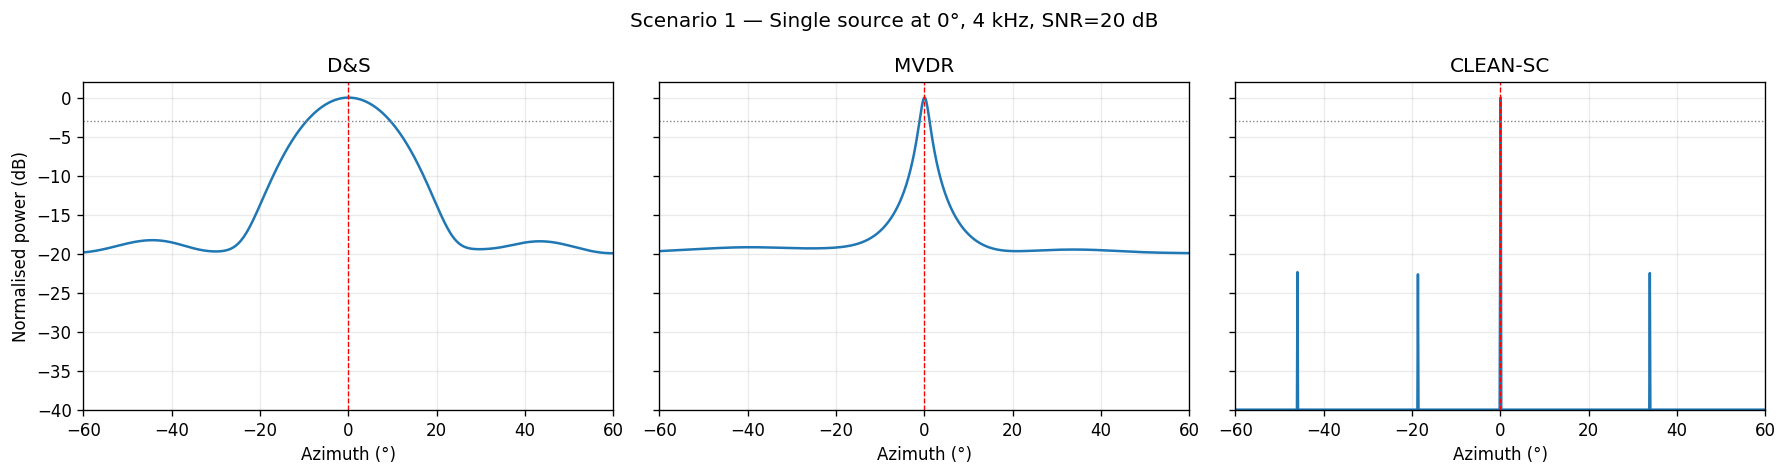

D&S         peak at +0.1°
MVDR        peak at +0.1°
CLEAN-SC    peak at +0.1°


In [5]:
freq = 4000
az_grid = scan_grid()
sources_1 = [(0.0, 1.0)]   # single source at 0°, unit power

R1 = make_csm(x_arr, y_arr, sources_1, freq, snr_db=20)

map_ds    = beamform_ds(x_arr, y_arr, R1, freq, az_grid)
map_mvdr  = beamform_mvdr(x_arr, y_arr, R1, freq, az_grid)
map_clean = beamform_cleansc(x_arr, y_arr, R1, freq, az_grid)


def to_db(m, floor_db=-40):
    with np.errstate(divide='ignore'):
        db = 10 * np.log10(m / m.max())
    return np.clip(db, floor_db, 0)


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, label, m in zip(axes,
                         ['D&S', 'MVDR', 'CLEAN-SC'],
                         [map_ds, map_mvdr, map_clean]):
    ax.plot(az_grid, to_db(m))
    ax.axvline(0, color='red', linestyle='--', linewidth=0.8, label='true source')
    ax.axhline(-3,  color='gray', linestyle=':', linewidth=0.8)
    ax.set_xlim(-60, 60)
    ax.set_ylim(-40, 2)
    ax.set_title(label)
    ax.set_xlabel('Azimuth (°)')
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel('Normalised power (dB)')
fig.suptitle(f'Scenario 1 — Single source at 0°, {freq//1000} kHz, SNR=20 dB')
plt.tight_layout()
plt.savefig('algo_single_source.png', dpi=150, bbox_inches='tight')
plt.show()

for label, m in [('D&S', map_ds), ('MVDR', map_mvdr), ('CLEAN-SC', map_clean)]:
    doa = az_grid[np.argmax(m)]
    print(f"{label:10s}  peak at {doa:+.1f}°")

## Scenario 2 — Two Equal Sources, Well Separated (30°)

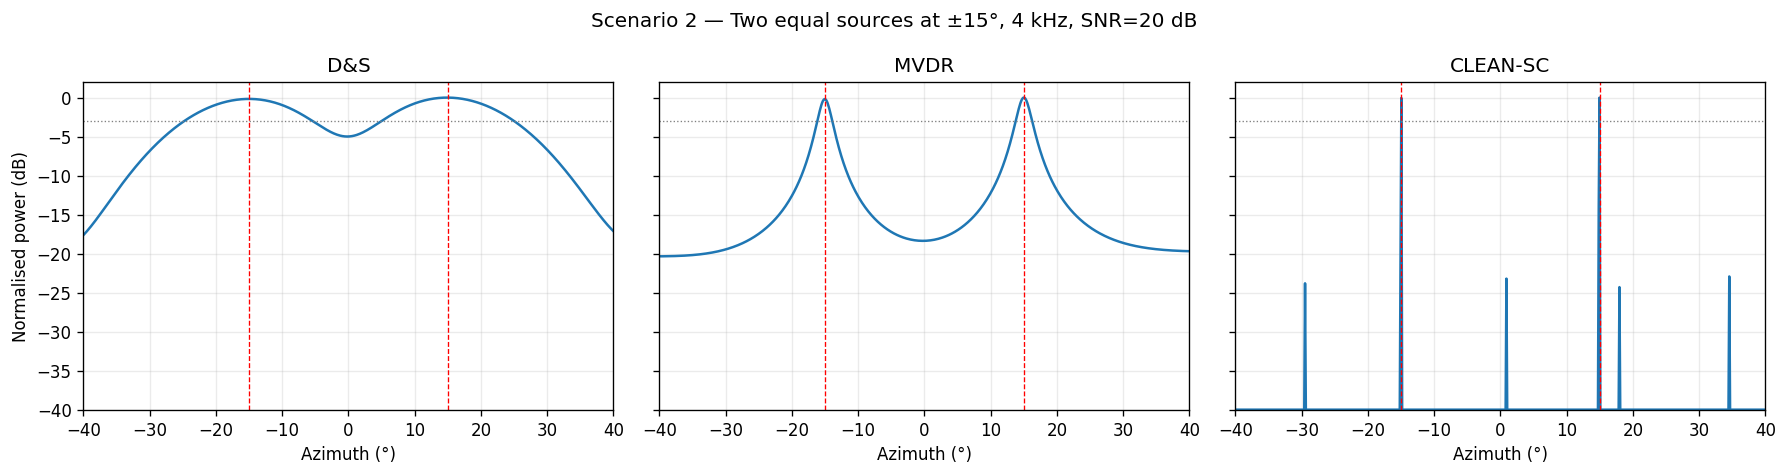

In [6]:
sources_2a = [(-15.0, 1.0), (15.0, 1.0)]

R2a = make_csm(x_arr, y_arr, sources_2a, freq, snr_db=20)

map_ds_2a    = beamform_ds(x_arr, y_arr, R2a, freq, az_grid)
map_mvdr_2a  = beamform_mvdr(x_arr, y_arr, R2a, freq, az_grid)
map_clean_2a = beamform_cleansc(x_arr, y_arr, R2a, freq, az_grid, n_iter=20)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, label, m in zip(axes,
                         ['D&S', 'MVDR', 'CLEAN-SC'],
                         [map_ds_2a, map_mvdr_2a, map_clean_2a]):
    ax.plot(az_grid, to_db(m))
    for az_true in [-15, 15]:
        ax.axvline(az_true, color='red', linestyle='--', linewidth=0.8)
    ax.axhline(-3, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xlim(-40, 40)
    ax.set_ylim(-40, 2)
    ax.set_title(label)
    ax.set_xlabel('Azimuth (°)')
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel('Normalised power (dB)')
fig.suptitle(f'Scenario 2 — Two equal sources at ±15°, {freq//1000} kHz, SNR=20 dB')
plt.tight_layout()
plt.savefig('algo_two_sources_30deg.png', dpi=150, bbox_inches='tight')
plt.show()

## Scenario 3 — Two Equal Sources, Near HPBW Limit (~9°)

At 4 kHz the array HPBW is ~19°.  Separating two sources by 9° (≈ 0.5 × HPBW) tests
super-resolution capability.

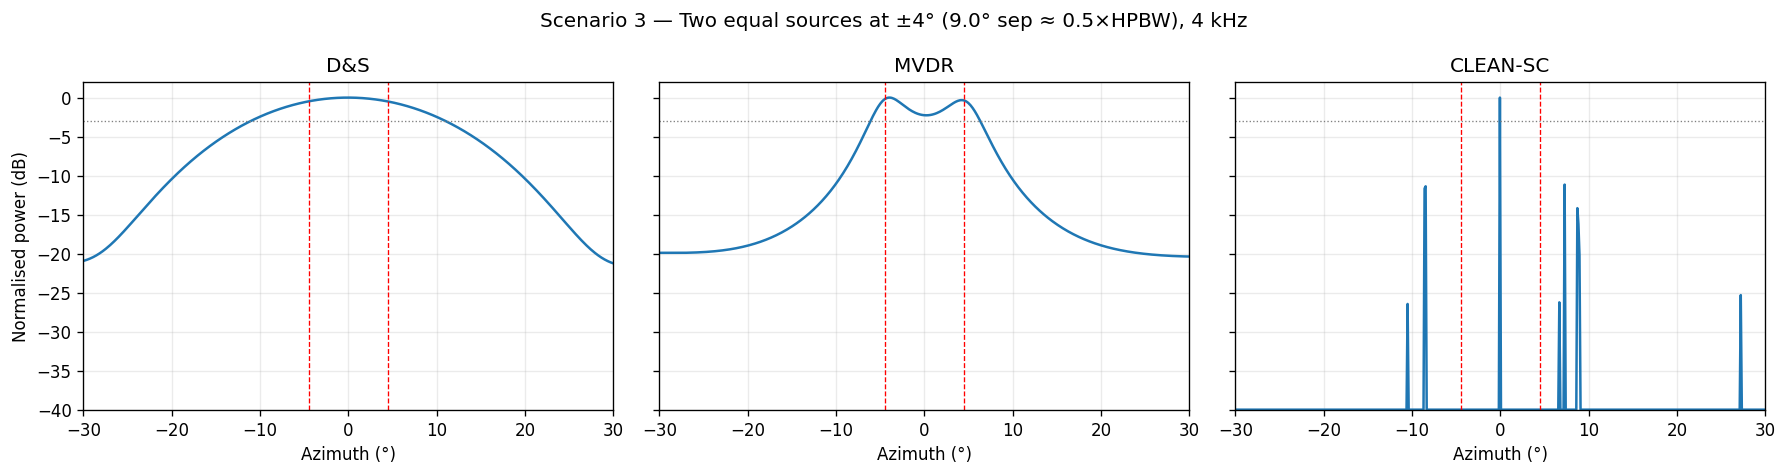

In [7]:
sep = 9.0   # degrees — approx 0.5× HPBW at 4 kHz
sources_2b = [(-sep/2, 1.0), (sep/2, 1.0)]

R2b = make_csm(x_arr, y_arr, sources_2b, freq, snr_db=20)

map_ds_2b    = beamform_ds(x_arr, y_arr, R2b, freq, az_grid)
map_mvdr_2b  = beamform_mvdr(x_arr, y_arr, R2b, freq, az_grid)
map_clean_2b = beamform_cleansc(x_arr, y_arr, R2b, freq, az_grid, n_iter=20)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, label, m in zip(axes,
                         ['D&S', 'MVDR', 'CLEAN-SC'],
                         [map_ds_2b, map_mvdr_2b, map_clean_2b]):
    ax.plot(az_grid, to_db(m))
    for az_true in [-sep/2, sep/2]:
        ax.axvline(az_true, color='red', linestyle='--', linewidth=0.8)
    ax.axhline(-3, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xlim(-30, 30)
    ax.set_ylim(-40, 2)
    ax.set_title(label)
    ax.set_xlabel('Azimuth (°)')
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel('Normalised power (dB)')
fig.suptitle(f'Scenario 3 — Two equal sources at ±{sep/2:.0f}° ({sep}° sep ≈ 0.5×HPBW), {freq//1000} kHz')
plt.tight_layout()
plt.savefig('algo_two_sources_close.png', dpi=150, bbox_inches='tight')
plt.show()

## Scenario 4 — Two Sources, 20 dB Power Difference

Weak source detection: strong source at −15°, weak source (−20 dB) at +10°.

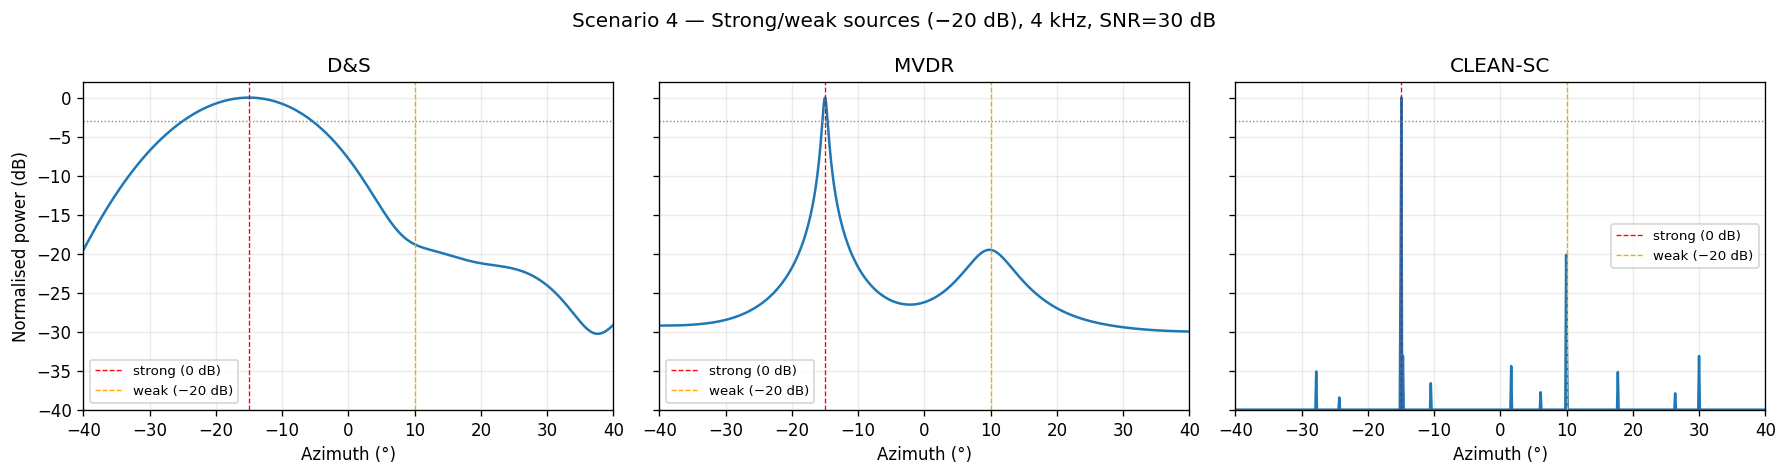

In [8]:
dynamic_range_db = 20.0
sources_dyn = [(-15.0, 1.0), (10.0, 10**(-dynamic_range_db/10))]

R_dyn = make_csm(x_arr, y_arr, sources_dyn, freq, snr_db=30)

map_ds_dyn    = beamform_ds(x_arr, y_arr, R_dyn, freq, az_grid)
map_mvdr_dyn  = beamform_mvdr(x_arr, y_arr, R_dyn, freq, az_grid)
map_clean_dyn = beamform_cleansc(x_arr, y_arr, R_dyn, freq, az_grid, n_iter=30)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, label, m in zip(axes,
                         ['D&S', 'MVDR', 'CLEAN-SC'],
                         [map_ds_dyn, map_mvdr_dyn, map_clean_dyn]):
    ax.plot(az_grid, to_db(m))
    ax.axvline(-15, color='red',    linestyle='--', linewidth=0.8, label='strong (0 dB)')
    ax.axvline( 10, color='orange', linestyle='--', linewidth=0.8, label=f'weak (−{dynamic_range_db:.0f} dB)')
    ax.axhline(-3,  color='gray',   linestyle=':', linewidth=0.8)
    ax.set_xlim(-40, 40)
    ax.set_ylim(-40, 2)
    ax.set_title(label)
    ax.set_xlabel('Azimuth (°)')
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Normalised power (dB)')
fig.suptitle(f'Scenario 4 — Strong/weak sources (−{dynamic_range_db:.0f} dB), {freq//1000} kHz, SNR=30 dB')
plt.tight_layout()
plt.savefig('algo_dynamic_range.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Table — All Scenarios

In [9]:
def doa_error(m, az_grid, true_az):
    """Error of the map's nearest peak to the given true azimuth."""
    peak = az_grid[np.argmax(m)]
    return abs(peak - true_az)


def two_source_resolved(m, az_grid, az1, az2, threshold_db=-3):
    """True if a valley between the two azimuths dips threshold_db below each peak."""
    db = to_db(m)
    lo, hi = sorted([az1, az2])
    between = (az_grid > lo) & (az_grid < hi)
    if not between.any():
        return False
    valley  = db[between].min()
    peak_lo = db[np.argmin(np.abs(az_grid - lo))]
    peak_hi = db[np.argmin(np.abs(az_grid - hi))]
    return valley < min(peak_lo, peak_hi) + threshold_db


# Recompute all scenarios so this cell runs independently of prior cells
_scenarios = [
    ('1: single @ 0°',         [(0.0, 1.0)],                              20, [0.0],         None,           10),
    ('2: ±15° (30° sep)',       [(-15.0, 1.0), (15.0, 1.0)],              20, [-15.0, 15.0], (-15.0, 15.0),  20),
    ('3: ±4.5° (9° sep)',       [(-4.5, 1.0), (4.5, 1.0)],                20, [-4.5, 4.5],   (-4.5, 4.5),    20),
    ('4: −20 dB weak source',   [(-15.0, 1.0), (10.0, 10**(-20/10))],      30, [-15.0],        (-15.0, 10.0),  30),
]

rows = []
for scenario, sources, snr, true_azs, resolve_pair, n_iter in _scenarios:
    R = make_csm(x_arr, y_arr, sources, freq, snr_db=snr)
    maps = {
        'D&S':      beamform_ds(x_arr, y_arr, R, freq, az_grid),
        'MVDR':     beamform_mvdr(x_arr, y_arr, R, freq, az_grid),
        'CLEAN-SC': beamform_cleansc(x_arr, y_arr, R, freq, az_grid, n_iter=n_iter),
    }
    for label, m in maps.items():
        err = round(doa_error(m, az_grid, true_azs[0]), 1) if len(true_azs) == 1 else '—'
        if resolve_pair is not None:
            res = 'Yes' if two_source_resolved(m, az_grid, *resolve_pair) else 'No'
        else:
            res = '—'
        rows.append({'Scenario': scenario, 'Algorithm': label,
                     'DoA error (°)': err, 'Resolved': res})

pd.DataFrame(rows).set_index(['Scenario', 'Algorithm'])

DoA error (°) Resolved
Scenario              Algorithm                       
1: single @ 0°        D&S                 0.1        —
                      MVDR                0.1        —
                      CLEAN-SC            0.1        —
2: ±15° (30° sep)     D&S                   —      Yes
                      MVDR                  —      Yes
                      CLEAN-SC              —      Yes
3: ±4.5° (9° sep)     D&S                   —       No
                      MVDR                  —       No
                      CLEAN-SC              —       No
4: −20 dB weak source D&S                 0.0       No
                      MVDR                0.1      Yes
                      CLEAN-SC            0.0       No

## SNR Sensitivity — DoA Error vs. SNR (Single Source)

How does DoA accuracy degrade as SNR drops from 30 dB to 0 dB?

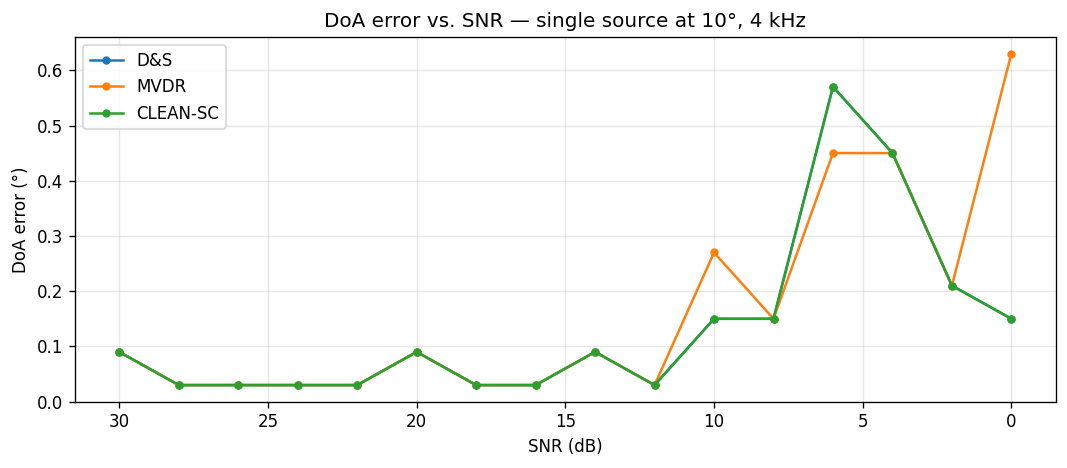

In [10]:
snr_range = np.arange(0, 32, 2)
results   = {name: [] for name in ['D&S', 'MVDR', 'CLEAN-SC']}

for snr in snr_range:
    R_snr = make_csm(x_arr, y_arr, [(10.0, 1.0)], freq, snr_db=snr)
    for label, fn in [('D&S',     lambda R: beamform_ds(x_arr, y_arr, R, freq, az_grid)),
                      ('MVDR',    lambda R: beamform_mvdr(x_arr, y_arr, R, freq, az_grid)),
                      ('CLEAN-SC',lambda R: beamform_cleansc(x_arr, y_arr, R, freq, az_grid))]:
        m   = fn(R_snr)
        err = doa_error(m, az_grid, 10.0)
        results[label].append(err)

fig, ax = plt.subplots(figsize=(9, 4))
for label, errors in results.items():
    ax.plot(snr_range, errors, marker='o', markersize=4, label=label)
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('DoA error (°)')
ax.set_title(f'DoA error vs. SNR — single source at 10°, {freq//1000} kHz')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()
plt.tight_layout()
plt.savefig('algo_snr_sweep.png', dpi=150, bbox_inches='tight')
plt.show()